In [2]:
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, callbacks,utils
from imblearn.over_sampling import ADASYN,SMOTE
from collections import Counter
from keras.optimizers import Adam

from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [3]:
df=pd.read_csv("combined_air_quality_modified.csv")
df = df.dropna(subset=['status'])
df.head()

,country,date,county,sitename,aqi,status,pm2.5,pm10,no,no2,nox,co,so2,o3,siteid
0,Philippines,2014-01-01,NCR,Manila,118.0,Unhealthy for Sensitive Groups,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,NaN
1,Philippines,2014-02-01,NCR,Manila,95.0,Moderate,32.926035,77.352669,22.808572,57.520162,42.574229,0.793464,19.536258,44.687065,NaN
2,Philippines,2014-03-01,NCR,Manila,124.0,Unhealthy for Sensitive Groups,44.715328,99.910623,34.325038,54.807419,47.240203,1.000999,26.546239,26.985845,NaN
3,Philippines,2014-04-01,NCR,Manila,152.0,Unhealthy for Sensitive Groups,57.845448,138.179877,20.041346,80.667124,53.375489,1.428835,34.518627,48.524207,NaN
4,Philippines,2014-05-01,NCR,Manila,92.0,Moderate,31.487699,70.390261,22.100780,56.562426,41.691499,1.120790,17.809835,51.075438,NaN


In [4]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['status']
X=df[features]
y=df[status]  


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [7]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [8]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
print(X_scaled.shape)

(116436, 8)


In [10]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    
    
    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # Second Dense layer
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'

    ]
)

In [12]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_rf_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [ ]:
model.fit(
X_scaled, y_train,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks)#training nn

SyntaxError: unmatched ')' (1796088944.py, line 10)

In [22]:
best_model=tf.keras.models.load_model("best_model_rf_classifier.keras")
nn_predictions = best_model.predict(X_scaled)
y_pseudo_train = np.argmax(nn_predictions, axis=1)

# 2. Train the Random Forest on the tabular data using the NN's pseudo-labels
rf_distilled = RandomForestClassifier(n_estimators=300,
                                      min_samples_split=5,
                                      min_samples_leaf=1,
                                      max_features="sqrt",
                                      max_depth=20,
                                      bootstrap=False)
rf_distilled.fit(X_scaled, y_pseudo_train)

# 3. Scale and prepare your raw test subset
X_test_scaled = scaler.transform(X_test)

# 4. Predict using the distilled Random Forest model
y_pred_rf = rf_distilled.predict(X_test_scaled)

print("--- Distilled Random Forest Performance (Normal NN Teacher) ---")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

3639/3639 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
--- Distilled Random Forest Performance (Normal NN Teacher) ---
                                precision    recall  f1-score   support

                          Good       0.95      0.98      0.97     24132
                      Moderate       0.90      0.75      0.82      4653
Unhealthy for Sensitive Groups       1.00      0.89      0.94       324

                      accuracy                           0.95     29109
                     macro avg       0.95      0.88      0.91     29109
                  weighted avg       0.94      0.95      0.94     29109



In [23]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Convert y_test from a 2D one-hot matrix to 1D integer labels
y_test_ground_truth = y_test

# Fix: Changed y_pred to y_pred_rf
accuracy = accuracy_score(y_test_ground_truth, y_pred_rf)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_ground_truth, y_pred_rf, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  94.56%
Precision: 0.9441
Recall:    0.9456
F1-Score:  0.9436


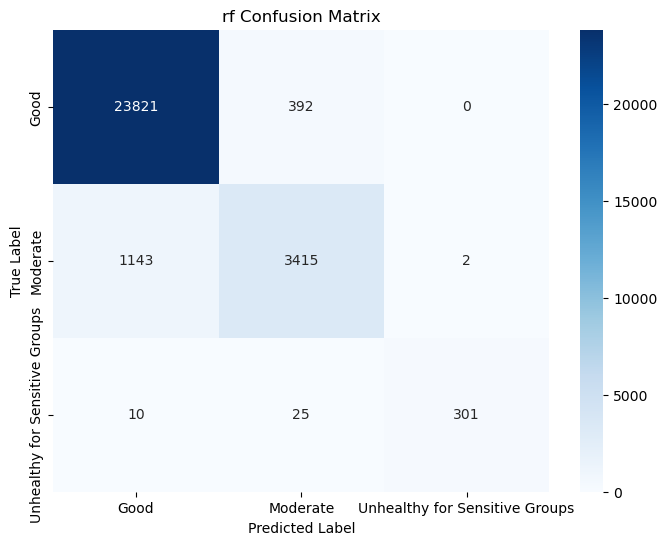

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Convert y_test from one-hot encoding to integer labels
y_test_labels = y_test

# 2. Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_rf)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('rf Confusion Matrix')
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import joblib

# 1. Define the parameter search space for the Random Forest Classifier
param_dist_rf_clf = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [None, 10, 15, 20, 25],      # Max depth of trees
    'min_samples_split': [2, 5, 10],           # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],             # Minimum samples required at each leaf node
    'max_features': ['sqrt', 'log2', None],    # Number of features to consider at every split
    'bootstrap': [True, False]                 # Whether bootstrap samples are used when building trees
}

# 2. Initialize the baseline RandomForestClassifier
rf_clf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Configure the Randomized Search
print("Starting Hyperparameter Tuning for Random Forest Classifier...")
rf_clf_search = RandomizedSearchCV(
    estimator=rf_clf_base,
    param_distributions=param_dist_rf_clf,
    n_iter=10,             # Evaluates 10 completely random setups
    cv=3,                  # 3-Fold Stratified Cross Validation
    scoring='accuracy',    # Optimize to maximize matching the teacher labels
    random_state=42,
    n_jobs=-1
)

# 4. Fit the search on your scaled training metrics and teacher pseudo-labels
rf_clf_search.fit(X_scaled, y_pseudo_train)

# 5. Extract and print the best model configuration
print("\n✅ Best Random Forest Classifier Parameters Found:")
print(rf_clf_search.best_params_)

best_rf_clf = rf_clf_search.best_estimator_

# 6. Evaluate on your scaled test set
X_test_scaled = scaler.transform(X_test)
y_pred_rf_clf = best_rf_clf.predict(X_test_scaled)

print("\n--- Tuned Distilled Random Forest Classifier Performance ---")
print(classification_report(y_test, y_pred_rf_clf, target_names=le.classes_, zero_division=0))



Starting Hyperparameter Tuning for Random Forest Classifier...

✅ Best Random Forest Classifier Parameters Found:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

--- Tuned Distilled Random Forest Classifier Performance ---
                                precision    recall  f1-score   support

                          Good       0.78      0.00      0.00     24132
                      Moderate       0.20      0.12      0.15      4653
Unhealthy for Sensitive Groups       0.01      0.98      0.02       324

                      accuracy                           0.03     29109
                     macro avg       0.33      0.37      0.06     29109
                  weighted avg       0.68      0.03      0.03     29109

